# Kapitel 4 – Klassificering

Individuella övningsuppgifter.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Fråga 1

### Vad kännetecknar klassificeringsproblem? Ge några exempel på tillämpningsområden.

Klassificering används när målet är att förutsäga vilken **klass eller kategori** en observation tillhör.

Exempel är spam/inte spam, sjuk/frisk, om en kund lämnar eller stannar och vilken siffra som finns på en bild.

Till skillnad från regression försöker man alltså inte förutsäga ett kontinuerligt numeriskt värde.

## Fråga 2

### Förklara hur OvR- och OvO-algoritmerna fungerar.

**OvR (One-vs-Rest)** tränar en modell för varje klass där den klassen jämförs mot alla andra.

Har vi A, B och C blir det A mot resten, B mot resten och C mot resten.

**OvO (One-vs-One)** tränar istället en modell för varje par av klasser: A mot B, A mot C och B mot C.

OvO kräver därför fler modeller när antalet klasser blir stort.

## Fråga 3

### Förklara följande utvärderingsmått.

#### a) Confusion matrix

En confusion matrix visar hur modellens prediktioner fördelar sig mellan rätt och fel klassificeringar.

För binär klassificering brukar man prata om True Positive, True Negative, False Positive och False Negative.

![image](./img_4/confusion_matrix.png)


#### b) Accuracy

Accuracy är antalet observationer som modellen klassificerat rätt sammanlagt. Det kan bli missvisande om klasserna är väldigt obalanserade.

#### c) Precision

Precision visar hur stor andel av modellens positiva prediktioner som faktiskt var positiva. Hög precision innebär få false positives.

#### d) Recall

Recall visar hur stor andel av de faktiskt positiva observationerna som modellen lyckas hitta. Hög recall innebär få false negatives.

#### e) F1-score

F1-score kombinerar precision och recall i ett enda mått. Det är användbart när man vill ha en balans mellan båda.

#### f) ROC-kurvan

ROC-kurvan visar hur true positive rate och false positive rate förändras när klassificerings-threshold ändras.

ROC-AUC sammanfattar kurvan i ett värde. Högre värde betyder bättre förmåga att skilja klasserna åt.

## Fråga 4

### Vad är precision-recall tradeoff för något?

Precision och recall påverkar ofta varandra.

Om man höjer kravet för att något ska klassas som positivt får man ofta färre false positives och högre precision, men samtidigt kan fler riktiga positiva observationer missas och recall sjunker.

Sänker man tröskeln kan man få högre recall men fler false positives.

Man behöver alltså välja balans beroende på vilken typ av fel som är ""värst" i problemet.

## Fråga 5

### Några vanligt förekommande modeller för klassificeringsproblem är enligt nedan. Förklara översiktligt hur respektive modell fungerar.

#### a) Logistisk regression

Logistisk regression räknar fram en sannolikhet för att en observation tillhör en viss klass. Sannolikheten jämförs sedan med en tröskel, exempelvis 0.5.

#### b) Support Vector Machines

SVM försöker hitta en beslutsgräns som separerar klasserna med så stor marginal som möjligt. Med kernels kan den även hantera icke-linjära gränser.

#### c) Beslutsträd

Ett beslutsträd delar upp datan steg för steg utifrån villkor på variablerna. Slutnoden avgör vilken klass observationen får. (Är en observation <= 0.5, gå vänster, annars gå höger)

#### d) Ensemble learning

Ensemble learning kombinerar flera modeller.

VotingClassifier kombinerar flera modellers prediktioner. BaggingClassifier tränar flera modeller på olika delar av datan och kombinerar resultatet.

#### e) Random Forest

Random Forest består av många beslutsträd som tränas på olika urval av observationer och features, trädens prediktioner kombineras.

#### f) Extra Trees

Extra Trees liknar Random Forest men använder ännu mer slumpmässighet när träden byggs, bland annat vid val av split-punkter.

## Fråga 6

### Vad innebär det att vi kan kolla på feature importance med hjälp av trädmodeller såsom beslutsträd eller Random Forest?

Feature importance visar vilka variabler modellen haft mest nytta av när den delat datan och gjort prediktioner.

Ett högt värde betyder att en featurehar bidragit mycket till modellens beslut.

Det kan hjälpa oss förstå modellen, men hög feature importance betyder inte automatiskt att variabeln orsakar korrelationen.

## Fråga 7

### Stina säger att hon vill ha högsta möjliga precision. Kalle frågar vad som då händer med recall. Hur kan man resonera kring detta?

Om man försöker maximera precision brukar recall sjunka.

Hög precision betyder att de observationer modellen klassar som positiva oftast verkligen är positiva. För att nå det kan modellen behöva vara mer försiktig och då missa fler äkta positiva fall.

Hög precision är viktigt när false positives är dyra eller allvarliga (tänk feldiagnostisering av en patient som faktiskt är allvarligt sjuk).

I rättsväsendet, där en positiv klassificering i värsta fall kan bidra till fängelse, är false positives väldigt allvarliga. Samtidigt kan för låg recall innebära att folk som faktiskt är skyldiga missas.

Man måste därför väga konsekvenserna av båda typerna av fel mot varandra, detta är något man anpassar efter klassificeringsproblemet man har.

## Fråga 8

### Förklara hur man kan tolka figur 4.8 på sidan 175.

Figuren visar beslutsgränsen för en logistisk regressionsmodell med två features, `X1` och `X2`.

Punkterna visar olika observationer från X1 och X2. Bakgrundsfärgen visar sannolikheten mellan 0 och 1 att en punkt tillhör klass 1.

Mörklila betyder låg sannolikhet och gult betyder hög sannolikhet.

Det viktiga är att modellen först räknar fram en sannolikhet. Beslutsgränsen ligger där sannolikheten passerar den tröskel som används för att välja mellan X1 och X2.

Övergången är gradvis (0/lila, 1/gul), så punkter nära gränsen är mer osäkra än punkter långt från den.

![image](./img_4/beslutsgränser.png)


## Fråga 9

### På träningsdatan använder vi `.fit_transform()`, på valideringsdatan och testdatan använder vi endast `.transform()`. Förklara logiken bakom detta.

På träningsdatan använder vi .fit_transform() eftersom preprocessorn först behöver lära sig de bästa parametrarna från träningsdatan och sedan transformera datan.

Det kan exempelvis vara medelvärde och standardavvikelse i en StandardScaler.

På validerings- och testdatan använder vi bara .transform().

Annars skulle information från validerings- eller testdatan påverka preprocessingen och ge dataläckage.

All preprocessing ska alltså läras från träningsdatan och sedan göras på övrig data.

## Fråga 11

### Förklara vad nedanstående kod gör och tolka resultatet från koden.

Koden jämför de riktiga klasserna i y_true med prediktionerna i y_pred. (Läs y - y hat)

classification_report() räknar ut precision, recall, F1-score och support för varje klass. 

In [2]:
from sklearn.metrics import classification_report

y_true = [0, 1, 2, 2, 2]
y_pred = [0, 0, 2, 2, 1]
target_names = ["class 0", "class 1", "class 2"]

print(classification_report(y_true, y_pred, target_names=target_names))

              precision    recall  f1-score   support

     class 0       0.50      1.00      0.67         1
     class 1       0.00      0.00      0.00         1
     class 2       1.00      0.67      0.80         3

    accuracy                           0.60         5
   macro avg       0.50      0.56      0.49         5
weighted avg       0.70      0.60      0.61         5



Class 0 har recall 1.0 eftersom endast en riktig observation av klass 0 hittades, men precisionen är lägre eftersom även en observation från klass 1 felaktigt klassades som 0 (false positive).

Class 1 presterar dåligt eftersom den enda riktiga observationen av klass 1 klassades fel.

Class 2 presterar bäst. Två av tre observationer hittades korrekt och de prediktioner modellen gjorde som klass 2 var korrekta.

Tabellen visar också accuracy för hela modellen och macro average samt weighted average.

## Fråga 13

### Gör ett komplett ML-flöde på `hr_employee_data.xlsx` där `left` är den beroende variabeln.

`left = 1` betyder att personen har lämnat företaget och `left = 0` betyder att personen jobbar kvar.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay,
)

In [ ]:
hr_path = Path("chapter_03_regression/data/hr_employee_data.xlsx")

df = pd.read_excel(hr_path)
df.head()

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,IND02438,0.38,0.53,2,157,3,0,1,0,sales,low
1,IND28133,0.80,0.86,5,262,6,0,1,0,sales,medium
2,IND07164,0.11,0.88,7,272,4,0,1,0,sales,medium
3,IND30478,0.72,0.87,5,223,5,0,1,0,sales,low
4,IND24003,0.37,0.52,2,159,3,0,1,0,sales,low


In [ ]:
print("Antal rader:", len(df))
print("Saknade värden:", int(df.isna().sum().sum()))
print()
print(df["left"].value_counts())
print()
print(df["left"].value_counts(normalize=True).round(3))

Antal rader: 14999
Saknade värden: 0

left
0    11428
1     3571
Name: count, dtype: int64

left
0    0.762
1    0.238
Name: proportion, dtype: float64


`Emp_Id` används inte som feature eftersom det bara är ett ID och inte beskriver den anställdes arbetssituation.

In [ ]:
X = df.drop(columns=["left", "Emp_Id"])
y = df["left"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(exclude="object").columns.tolist()

print("Kategoriska features:", categorical_features)
print("Numeriska features:", numerical_features)
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Kategoriska features: ['Department', 'salary']
Numeriska features: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years']
Train: (11999, 9)
Test: (3000, 9)


In [ ]:
preprocessor_logistic = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

logistic_model = Pipeline([
    ("preprocessor", preprocessor_logistic),
    ("model", LogisticRegression(max_iter=1000))
])

forest_model = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

### Modellval

Jag jämför logistisk regression och Random Forest med cross-validation på träningsdatan.

Eftersom datasetet inte är helt balanserat använder jag `f1` som scoring istället för att bara titta på accuracy.

In [ ]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": forest_model,
}

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring="f1",
        cv=5,
        n_jobs=-1
    )
    cv_results[name] = scores.mean()

pd.Series(cv_results, name="CV F1").sort_values(ascending=False)

Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 112, in start_daemon
RuntimeError: Failed to start artifact tool daemon (exited early)
Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/sprea

Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 112, in start_daemon
RuntimeError: Failed to start artifact tool daemon (exited early)


Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 112, in start_daemon
RuntimeError: Failed to start artifact tool daemon (exited early)
Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/sprea

Random Forest          0.979065
Logistic Regression    0.436777
Name: CV F1, dtype: float64

In [ ]:
best_name = max(cv_results, key=cv_results.get)
best_model = models[best_name]

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Vald modell:", best_name)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1:", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))

Vald modell: Random Forest
Accuracy: 0.99
Precision: 0.994
Recall: 0.964
F1: 0.979
ROC-AUC: 0.99


In [ ]:
cm = confusion_matrix(y_test, y_pred)

pd.DataFrame(
    cm,
    index=["Faktisk 0", "Faktisk 1"],
    columns=["Predikterad 0", "Predikterad 1"]
)

,Predikterad 0,Predikterad 1
Faktisk 0,2282,4
Faktisk 1,26,688


In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Stannat", "Lämnat"]
))

              precision    recall  f1-score   support

     Stannat       0.99      1.00      0.99      2286
      Lämnat       0.99      0.96      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.99      3000
weighted avg       0.99      0.99      0.99      3000



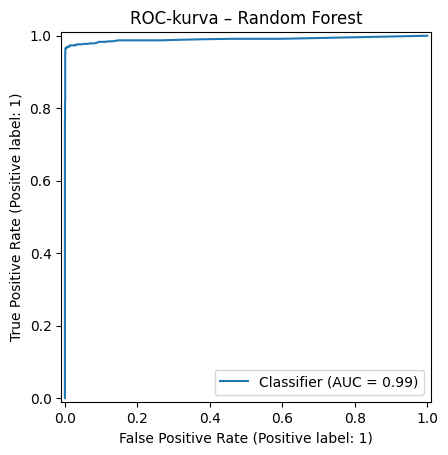

In [ ]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title(f"ROC-kurva – {best_name}")
plt.show()

### Slutsats

Jag gjorde först ett grundläggande preprocessing-flöde och jämförde två klassificeringsmodeller med cross-validation.

Den modell som fick högst F1-score valdes och utvärderades sedan på testdatan.

Jag tittade inte bara på accuracy utan även precision, recall, F1 och ROC-AUC eftersom `left` inte är helt balanserad.

Confusion matrix och classification report gör det tydligare vilken typ av fel modellen gör.

Resultatet kan användas som stöd för vidare analys, men det ska inte tolkas som att modellen kan förklara varför en person lämnar.